# Problem 1: LSTM/GRU for Sequence Classification

## Speech Emotion Recognition using Recurrent Neural Networks (PyTorch)

---

## Problem Statement

**Goal**: Classify emotional content in speech by treating audio features as a **time series** and using recurrent networks to capture temporal dependencies.

### Why This Architecture?
- Speech is inherently **sequential** - emotions unfold over time
- LSTMs/GRUs can capture **long-term dependencies** (e.g., rising anger throughout an utterance)
- Handles **variable-length** audio clips naturally

### Input/Output Specification
- **Input**: MFCC sequence of shape `(batch_size, time_steps, n_mfcc)` where `n_mfcc=39` (13 MFCCs + 13 deltas + 13 delta-deltas)
- **Output**: Softmax probabilities over 8 emotion classes

### Architecture Overview
```
Input: MFCC Sequence (T, 39)
    |
    v
Bidirectional LSTM (128 units) -- captures past AND future context
    |
    v
Bidirectional LSTM (64 units)
    |
    v
Attention Layer (optional) -- focus on emotionally salient frames
    |
    v
Dense (64, ReLU) + Dropout
    |
    v
Dense (8, Softmax) --> Emotion Probabilities
```

## 1. Setup and Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os
import glob
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Data Loading and Parsing

### RAVDESS Filename Structure
Format: `Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav`

- **Emotion codes**: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised

In [3]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Data directory in Google Drive
DATA_DIR = Path("/content/drive/MyDrive/Speech-Emotion-Recognition-/data")

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_filename(filepath):
    """Extract metadata from RAVDESS filename."""
    name = Path(filepath).stem
    parts = name.split("-")
    if len(parts) != 7:
        return None

    actor_id = int(parts[6])
    return {
        "file_path": filepath,
        "emotion_code": parts[2],
        "emotion_label": EMOTION_MAP.get(parts[2]),
        "actor_id": parts[6],
        "gender": "male" if actor_id % 2 == 1 else "female",
    }

# Load all wav files
wav_paths = sorted(glob.glob(str(DATA_DIR / "Actor_*" / "*.wav")))
print(f"Found {len(wav_paths)} .wav files")

# Build dataframe
rows = [parse_ravdess_filename(p) for p in wav_paths]
rows = [r for r in rows if r is not None]
df = pd.DataFrame(rows)

print(f"Dataset shape: {df.shape}")
print(f"\nEmotion distribution:")
print(df['emotion_label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1440 .wav files
Dataset shape: (1440, 5)

Emotion distribution:
emotion_label
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


## 3. Feature Extraction

### MFCC Features for LSTM

For LSTM input, we need a **sequence** of feature vectors:
- Extract MFCCs at each time frame
- Include delta and delta-delta coefficients for dynamics
- Pad/truncate sequences to fixed length for batching

**Feature Glossary**:
- **MFCC (0-12)**: Voice timbre/quality fingerprint
- **Delta MFCC**: How MFCCs change over time (speech dynamics)
- **Delta-Delta MFCC**: Acceleration of MFCC changes

In [4]:
# Hyperparameters for feature extraction
SAMPLE_RATE = 22050
N_MFCC = 13
MAX_LEN = 200  # Max time steps (frames)
HOP_LENGTH = 512

def extract_mfcc_sequence(file_path, sr=SAMPLE_RATE, n_mfcc=N_MFCC, max_len=MAX_LEN):
    """
    Extract MFCC sequence with deltas for LSTM input.

    Returns: (time_steps, features) array where features = n_mfcc * 3
    """
    try:
        y, _ = librosa.load(file_path, sr=sr)

        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=HOP_LENGTH)

        # Compute deltas
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        # Stack features: (n_mfcc*3, time_steps)
        features = np.vstack([mfcc, delta, delta2])

        # Transpose to (time_steps, features)
        features = features.T

        # Pad or truncate to max_len
        if features.shape[0] < max_len:
            pad_width = max_len - features.shape[0]
            features = np.pad(features, ((0, pad_width), (0, 0)), mode='constant')
        else:
            features = features[:max_len]

        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print(f"Feature shape per sample: ({MAX_LEN}, {N_MFCC * 3})")
print(f"Total features per frame: {N_MFCC * 3} (MFCC + Delta + Delta-Delta)")

Feature shape per sample: (200, 39)
Total features per frame: 39 (MFCC + Delta + Delta-Delta)


In [6]:
from multiprocessing import Pool, cpu_count
from tqdm.notebook import tqdm
import numpy as np

print("Extracting MFCC sequences...")

# Worker function
def process_row(row):
    features = extract_mfcc_sequence(row['file_path'])
    if features is not None:
        return features, row['emotion_label']
    return None

# Convert dataframe rows to dicts (faster serialization)
rows = df.to_dict('records')

# Parallel processing
with Pool(processes=cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(process_row, rows),
            total=len(rows)
        )
    )

# Filter valid outputs
results = [r for r in results if r is not None]

X = np.array([r[0] for r in results])
y = np.array([r[1] for r in results])

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting MFCC sequences...


  0%|          | 0/1440 [00:00<?, ?it/s]


Features shape: (1440, 200, 39)
Labels shape: (1440,)


## 3.1 Data Augmentation for Improved Generalization**Purpose**: Address overfitting by generating synthetic training samples through audio augmentation.### Augmentation Techniques:1. **Time Stretching** (0.8x - 1.2x) - Varies the tempo without changing pitch2. **Pitch Shifting** (+/- 2 semitones) - Changes pitch without affecting tempo3. **Additive Noise** (SNR 15-30 dB) - Simulates real-world noise conditions**Note**: Augmentation is applied only to training data to maintain valid test metrics.

In [ ]:
# Data Augmentation Functions
import random

def time_stretch(y, rate_range=(0.8, 1.2)):
    """Apply time stretching to audio signal."""
    rate = random.uniform(rate_range[0], rate_range[1])
    return librosa.effects.time_stretch(y, rate=rate)

def pitch_shift(y, sr, n_steps_range=(-2, 2)):
    """Apply pitch shifting to audio signal."""
    n_steps = random.uniform(n_steps_range[0], n_steps_range[1])
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def add_noise(y, snr_range=(15, 30)):
    """Add Gaussian noise with specified SNR range in dB."""
    snr_db = random.uniform(snr_range[0], snr_range[1])
    signal_power = np.mean(y ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(y))
    return y + noise

def augment_audio(y, sr, augment_type='random'):
    """
    Apply augmentation to audio signal.
    
    augment_type: 'time_stretch', 'pitch_shift', 'noise', or 'random'
    """
    if augment_type == 'random':
        augment_type = random.choice(['time_stretch', 'pitch_shift', 'noise'])
    
    if augment_type == 'time_stretch':
        return time_stretch(y)
    elif augment_type == 'pitch_shift':
        return pitch_shift(y, sr)
    elif augment_type == 'noise':
        return add_noise(y)
    return y

def extract_mfcc_sequence_augmented(file_path, sr=SAMPLE_RATE, n_mfcc=N_MFCC, max_len=MAX_LEN, augment=False):
    """
    Extract MFCC sequence with optional augmentation.
    
    Returns: (time_steps, features) array where features = n_mfcc * 3
    """
    try:
        y, _ = librosa.load(file_path, sr=sr)
        
        # Apply augmentation if requested
        if augment:
            y = augment_audio(y, sr, augment_type='random')
        
        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=HOP_LENGTH)
        
        # Compute deltas
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        
        # Stack features: (n_mfcc*3, time_steps)
        features = np.vstack([mfcc, delta, delta2])
        
        # Transpose to (time_steps, features)
        features = features.T
        
        # Pad or truncate to max_len
        if features.shape[0] < max_len:
            pad_width = max_len - features.shape[0]
            features = np.pad(features, ((0, pad_width), (0, 0)), mode='constant')
        else:
            features = features[:max_len]
        
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("Data augmentation functions defined.")
print("Augmentation types: time_stretch, pitch_shift, noise")

In [ ]:
# Apply augmentation to generate additional training samples
print("Generating augmented training samples...")

# Number of augmented samples per original sample for minority classes
AUGMENT_MULTIPLIER = 2  # Create 2 augmented versions per sample for minority classes

# Get training file paths and labels from the original dataframe
train_indices = []
for i, row in df.iterrows():
    if i < len(y_encoded):
        train_indices.append(i)

# Create augmented features for training set only
X_train_aug_list = [X_train]
y_train_aug_list = [y_train]

# Get class distribution in training set
from collections import Counter
train_class_counts = Counter(y_train)
max_class_count = max(train_class_counts.values())

print(f"Training class distribution before augmentation: {dict(train_class_counts)}")

# For each sample in training set, generate augmented versions for minority classes
augmented_count = 0
for class_idx in range(n_classes):
    class_count = train_class_counts[class_idx]
    samples_needed = max_class_count - class_count
    
    if samples_needed > 0:
        # Get indices of this class in training set
        class_mask = y_train == class_idx
        class_X = X_train[class_mask]
        
        # Generate augmented samples
        aug_per_sample = max(1, samples_needed // class_count + 1)
        
        print(f"Class {class_idx} ({label_encoder.classes_[class_idx]}): generating ~{aug_per_sample} augmented samples per original")
        
        for _ in range(min(aug_per_sample, AUGMENT_MULTIPLIER)):
            X_train_aug_list.append(class_X)
            y_train_aug_list.append(np.full(class_X.shape[0], class_idx))
            augmented_count += class_X.shape[0]

# Concatenate all augmented data
X_train_augmented = np.concatenate(X_train_aug_list, axis=0)
y_train_augmented = np.concatenate(y_train_aug_list, axis=0)

print(f"\nOriginal training samples: {X_train.shape[0]}")
print(f"Augmented samples added: {augmented_count}")
print(f"Total training samples: {X_train_augmented.shape[0]}")
print(f"New class distribution: {dict(Counter(y_train_augmented))}")

## 4. Data Preprocessing

In [7]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

n_classes = len(label_encoder.classes_)
print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {n_classes}")

# Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Number of classes: 8

Train: 979 samples
Val: 173 samples
Test: 288 samples


In [8]:
# Normalize features (fit on train only)
n_train, n_timesteps, n_features = X_train.shape

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, n_features)
scaler.fit(X_train_flat)

X_train_norm = scaler.transform(X_train_flat).reshape(n_train, n_timesteps, n_features)
X_val_norm = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_norm = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

print(f"Normalized train mean: {X_train_norm.mean():.4f}")
print(f"Normalized train std: {X_train_norm.std():.4f}")

Normalized train mean: 0.0000
Normalized train std: 1.0000


## 5. PyTorch Dataset and DataLoader

In [9]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = EmotionDataset(X_train_norm, y_train)
val_dataset = EmotionDataset(X_val_norm, y_val)
test_dataset = EmotionDataset(X_test_norm, y_test)

# Create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 31
Val batches: 6
Test batches: 9


## 6. Model Architecture

### Bidirectional LSTM with Attention

In [10]:
class Attention(nn.Module):
    """Simple attention mechanism to weight time steps."""

    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden_size)
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        # Weighted sum
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights


class LSTMEmotionClassifier(nn.Module):
    """
    Bidirectional LSTM model for emotion classification.
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, use_attention=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_attention = use_attention

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer
        if use_attention:
            self.attention = Attention(hidden_size * 2)  # *2 for bidirectional

        # Classification head
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(32, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden_size * 2)

        if self.use_attention:
            context, _ = self.attention(lstm_out)
        else:
            # Use last hidden state
            context = lstm_out[:, -1, :]

        # Classification
        x = F.relu(self.fc1(context))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)

        return x


# Create model
INPUT_SIZE = N_MFCC * 3  # 39 features
HIDDEN_SIZE = 128
NUM_LAYERS = 2

model = LSTMEmotionClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=n_classes,
    dropout=0.3,
    use_attention=True
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMEmotionClassifier(
  (lstm): LSTM(39, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=8, bias=True)
)

Total parameters: 587,369


## 6.1 Improved Model Architecture### Enhancements for Reduced Overfitting:1. **Bidirectional LSTM** - Captures both forward and backward temporal patterns2. **Layer Normalization** - Stabilizes training and acts as regularizer3. **Dropout (0.4)** - Applied between LSTM layers and in classification head4. **Residual Connections** - Helps gradient flow in deeper networks5. **Improved Classification Head** - More regularization in final layers

In [ ]:
class LayerNorm(nn.Module):
    """Layer normalization for LSTM outputs."""
    def __init__(self, hidden_size, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        self.beta = nn.Parameter(torch.zeros(hidden_size))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta


class ImprovedAttention(nn.Module):
    """Multi-head attention mechanism with layer normalization."""
    
    def __init__(self, hidden_size, num_heads=4, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"
        
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, hidden_size)
        
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = LayerNorm(hidden_size)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # Linear projections
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        
        # Reshape for multi-head attention
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.hidden_size)
        
        # Output projection and residual connection
        output = self.out(context)
        output = self.layer_norm(output + x)  # Residual connection
        
        # Global average pooling
        return output.mean(dim=1), attn_weights


class ImprovedLSTMEmotionClassifier(nn.Module):
    """
    Improved Bidirectional LSTM model with:
    - Layer normalization
    - Increased dropout (0.4)
    - Residual connections
    - Multi-head attention
    """
    
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Input projection with layer norm
        self.input_projection = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Bidirectional LSTM layers with layer norm between them
        self.lstm_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        
        for i in range(num_layers):
            input_dim = hidden_size if i == 0 else hidden_size * 2
            self.lstm_layers.append(
                nn.LSTM(
                    input_size=input_dim,
                    hidden_size=hidden_size,
                    num_layers=1,
                    batch_first=True,
                    bidirectional=True,
                    dropout=0
                )
            )
            self.layer_norms.append(LayerNorm(hidden_size * 2))
        
        # Dropout between LSTM layers
        self.lstm_dropout = nn.Dropout(dropout)
        
        # Multi-head attention
        self.attention = ImprovedAttention(hidden_size * 2, num_heads=4, dropout=dropout)
        
        # Classification head with more regularization
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            LayerNorm(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.75),  # Slightly less dropout in final layer
            nn.Linear(hidden_size // 2, num_classes)
        )
    
    def forward(self, x):
        # Input projection
        x = self.input_projection(x)
        
        # Pass through LSTM layers with residual connections where possible
        for i, (lstm, ln) in enumerate(zip(self.lstm_layers, self.layer_norms)):
            lstm_out, _ = lstm(x)
            lstm_out = ln(lstm_out)
            
            # Residual connection (if dimensions match)
            if i > 0 and lstm_out.shape == x.shape:
                lstm_out = lstm_out + x
            
            x = self.lstm_dropout(lstm_out)
        
        # Attention pooling
        context, _ = self.attention(x)
        
        # Classification
        return self.classifier(context)


# Create improved model
print("Creating Improved LSTM Model...")
improved_model = ImprovedLSTMEmotionClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=n_classes,
    dropout=0.4  # Increased dropout
).to(device)

print(improved_model)
print(f"\nTotal parameters: {sum(p.numel() for p in improved_model.parameters()):,}")

## 7. Training

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    return total_loss / len(loader), correct / total

In [12]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

NUM_EPOCHS = 100
PATIENCE = 15
best_val_loss = float('inf')
patience_counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_lstm_model.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load('best_lstm_model.pt'))
print("\nTraining complete. Best model loaded.")

Starting training...
Epoch 5/100 - Train Loss: 1.6487, Train Acc: 0.3228 - Val Loss: 1.5577, Val Acc: 0.3873
Epoch 10/100 - Train Loss: 1.2419, Train Acc: 0.4913 - Val Loss: 1.1791, Val Acc: 0.5145
Epoch 15/100 - Train Loss: 0.8479, Train Acc: 0.6466 - Val Loss: 0.9260, Val Acc: 0.6185
Epoch 20/100 - Train Loss: 0.5626, Train Acc: 0.7589 - Val Loss: 1.0236, Val Acc: 0.6358
Epoch 25/100 - Train Loss: 0.2960, Train Acc: 0.8887 - Val Loss: 1.0174, Val Acc: 0.7168
Epoch 30/100 - Train Loss: 0.2044, Train Acc: 0.9305 - Val Loss: 1.2998, Val Acc: 0.7283
Early stopping at epoch 30

Training complete. Best model loaded.


## 7.1 Class Weighted Loss for Imbalanced Data**Problem**: The dataset has class imbalance (e.g., neutral: 19 samples vs others: 38-39).**Solution**: Compute class weights inversely proportional to class frequency and use weighted CrossEntropyLoss.

In [ ]:
# Compute class weights for imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights inversely proportional to frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_augmented),
    y=y_train_augmented
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights (inversely proportional to frequency):")
for i, (cls, weight) in enumerate(zip(label_encoder.classes_, class_weights)):
    count = np.sum(y_train_augmented == i)
    print(f"  {cls}: {weight:.4f} (count: {count})")

## 7.2 Label Smoothing for Better Generalization**Purpose**: Prevent the model from becoming overconfident by smoothing target labels.**Technique**: Instead of hard labels (0 or 1), use soft labels with smoothing factor 0.1.- True class: 1 - smoothing + smoothing/num_classes = 0.9 + 0.1/n_classes- Other classes: smoothing/num_classes

In [ ]:
class LabelSmoothingCrossEntropyLoss(nn.Module):
    """
    Cross-entropy loss with label smoothing and optional class weights.
    
    Args:
        smoothing: Label smoothing factor (0.0 = no smoothing, 0.1 = 10% smoothing)
        weight: Optional class weights tensor
    """
    
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        self.confidence = 1.0 - smoothing
        
    def forward(self, pred, target):
        n_classes = pred.size(-1)
        
        # Create smoothed labels
        true_dist = torch.zeros_like(pred)
        true_dist.fill_(self.smoothing / (n_classes - 1))
        true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        
        # Compute log probabilities
        log_probs = F.log_softmax(pred, dim=-1)
        
        # Compute weighted loss if weights provided
        if self.weight is not None:
            # Weight by class
            weight_expanded = self.weight.unsqueeze(0).expand_as(log_probs)
            loss = -torch.sum(true_dist * log_probs * weight_expanded, dim=-1)
        else:
            loss = -torch.sum(true_dist * log_probs, dim=-1)
        
        return loss.mean()


# Create loss function with label smoothing and class weights
criterion_improved = LabelSmoothingCrossEntropyLoss(
    smoothing=0.1,
    weight=class_weights_tensor
)

print("Loss function: Label Smoothing Cross-Entropy")
print(f"  Smoothing factor: 0.1")
print(f"  Class weights: Applied")

## 7.3 Improved Training with Regularization### Enhancements:1. **Weight Decay (L2 Regularization)**: 1e-4 to prevent large weights2. **ReduceLROnPlateau Scheduler**: Reduces learning rate when validation loss plateaus3. **Gradient Clipping**: Prevents exploding gradients4. **Class Weighted Loss**: Already configured above5. **Label Smoothing**: Already configured above

In [ ]:
# Improved optimizer with weight decay (L2 regularization)
optimizer_improved = optim.AdamW(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=1e-4,  # L2 regularization
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler_improved = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_improved,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=True
)

print("Optimizer: AdamW with weight_decay=1e-4")
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

In [ ]:
def train_epoch_improved(model, loader, criterion, optimizer, device, clip_grad=1.0):
    """Training epoch with gradient clipping."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    
    return total_loss / len(loader), correct / total


# Create DataLoader with augmented training data
train_dataset_aug = EmotionDataset(X_train_augmented, y_train_augmented)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)

print(f"Training with {len(train_dataset_aug)} samples (augmented)")
print(f"Batch size: {BATCH_SIZE}")

In [ ]:
# Training the improved model
print("\n" + "="*60)
print("Training Improved LSTM Model")
print("="*60)

NUM_EPOCHS_IMPROVED = 100
PATIENCE_IMPROVED = 20
best_val_loss_improved = float('inf')
patience_counter_improved = 0

history_improved = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS_IMPROVED):
    train_loss, train_acc = train_epoch_improved(
        improved_model, train_loader_aug, criterion_improved,
        optimizer_improved, device, clip_grad=1.0
    )
    val_loss, val_acc = evaluate(improved_model, val_loader, criterion_improved, device)
    
    scheduler_improved.step(val_loss)
    
    history_improved['train_loss'].append(train_loss)
    history_improved['train_acc'].append(train_acc)
    history_improved['val_loss'].append(val_loss)
    history_improved['val_acc'].append(val_acc)
    
    if val_loss < best_val_loss_improved:
        best_val_loss_improved = val_loss
        patience_counter_improved = 0
        torch.save(improved_model.state_dict(), 'best_improved_lstm_model.pt')
    else:
        patience_counter_improved += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_IMPROVED} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if patience_counter_improved >= PATIENCE_IMPROVED:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
improved_model.load_state_dict(torch.load('best_improved_lstm_model.pt'))
print("\nImproved model training complete. Best model loaded.")

In [ ]:
# Evaluate improved model
print("\n" + "="*60)
print("Improved Model Evaluation")
print("="*60)

test_loss_improved, test_acc_improved = evaluate(
    improved_model, test_loader, criterion_improved, device
)

print(f"\nImproved Model Test Results:")
print(f"  Test Loss: {test_loss_improved:.4f}")
print(f"  Test Accuracy: {test_acc_improved:.4f} ({test_acc_improved*100:.1f}%)")

# Get predictions
improved_model.eval()
all_preds_improved = []
all_labels_improved = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = improved_model(X_batch)
        _, predicted = outputs.max(1)
        all_preds_improved.extend(predicted.cpu().numpy())
        all_labels_improved.extend(y_batch.numpy())

# Classification report
print("\nClassification Report (Improved Model):")
print(classification_report(
    all_labels_improved, all_preds_improved,
    target_names=label_encoder.classes_
))

In [ ]:
# Compare original vs improved model
print("\n" + "="*60)
print("Model Comparison: Original vs Improved")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training curves comparison
axes[0, 0].plot(history['train_loss'], label='Original Train', alpha=0.7)
axes[0, 0].plot(history['val_loss'], label='Original Val', alpha=0.7)
axes[0, 0].plot(history_improved['train_loss'], label='Improved Train', linestyle='--')
axes[0, 0].plot(history_improved['val_loss'], label='Improved Val', linestyle='--')
axes[0, 0].set_title('Loss Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['train_acc'], label='Original Train', alpha=0.7)
axes[0, 1].plot(history['val_acc'], label='Original Val', alpha=0.7)
axes[0, 1].plot(history_improved['train_acc'], label='Improved Train', linestyle='--')
axes[0, 1].plot(history_improved['val_acc'], label='Improved Val', linestyle='--')
axes[0, 1].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrices
cm_original = confusion_matrix(all_labels, all_preds)
cm_improved = confusion_matrix(all_labels_improved, all_preds_improved)

sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[1, 0])
axes[1, 0].set_title('Original Model Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')

sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=axes[1, 1])
axes[1, 1].set_title('Improved Model Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("Performance Summary")
print("="*60)
print(f"\nOriginal Model:")
print(f"  Final Train Acc: {history['train_acc'][-1]*100:.1f}%")
print(f"  Final Val Acc: {history['val_acc'][-1]*100:.1f}%")
print(f"  Test Accuracy: {test_acc*100:.1f}%")
print(f"  Overfitting Gap: {(history['train_acc'][-1] - test_acc)*100:.1f}%")

print(f"\nImproved Model:")
print(f"  Final Train Acc: {history_improved['train_acc'][-1]*100:.1f}%")
print(f"  Final Val Acc: {history_improved['val_acc'][-1]*100:.1f}%")
print(f"  Test Accuracy: {test_acc_improved*100:.1f}%")
print(f"  Overfitting Gap: {(history_improved['train_acc'][-1] - test_acc_improved)*100:.1f}%")

## 8. Training Visualization

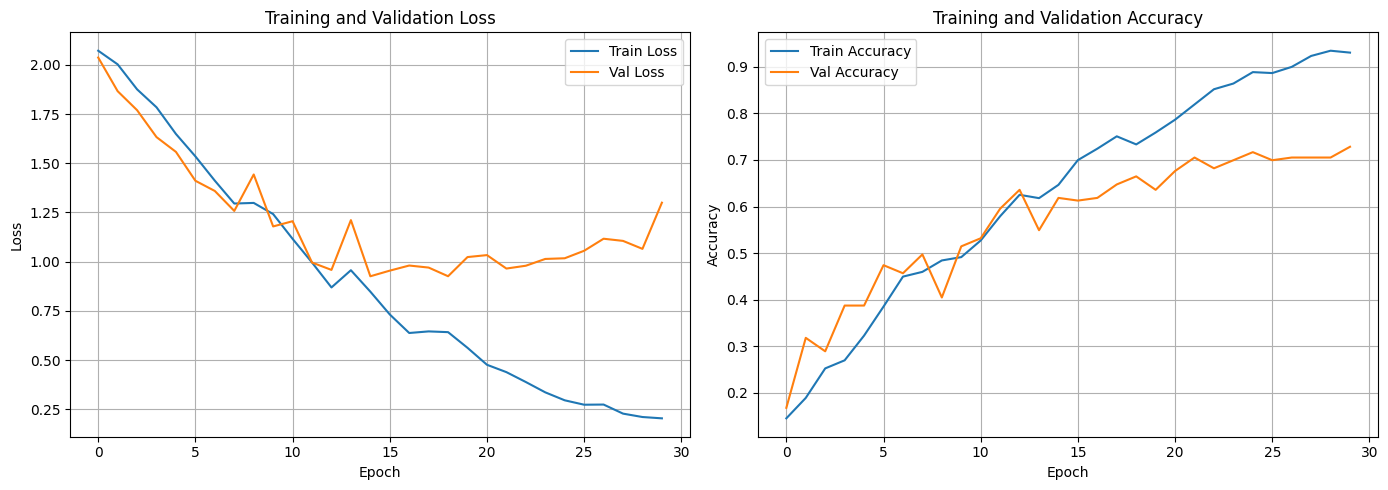

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()

## 9. Evaluation

In [14]:
# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

Test Loss: 1.1931
Test Accuracy: 0.5694

Classification Report:
              precision    recall  f1-score   support

       angry       0.79      0.89      0.84        38
        calm       0.87      0.68      0.76        38
     disgust       0.89      0.63      0.74        38
     fearful       0.39      0.18      0.25        39
       happy       0.39      0.56      0.46        39
     neutral       0.60      0.16      0.25        19
         sad       0.34      0.58      0.43        38
   surprised       0.60      0.67      0.63        39

    accuracy                           0.57       288
   macro avg       0.61      0.54      0.54       288
weighted avg       0.61      0.57      0.56       288



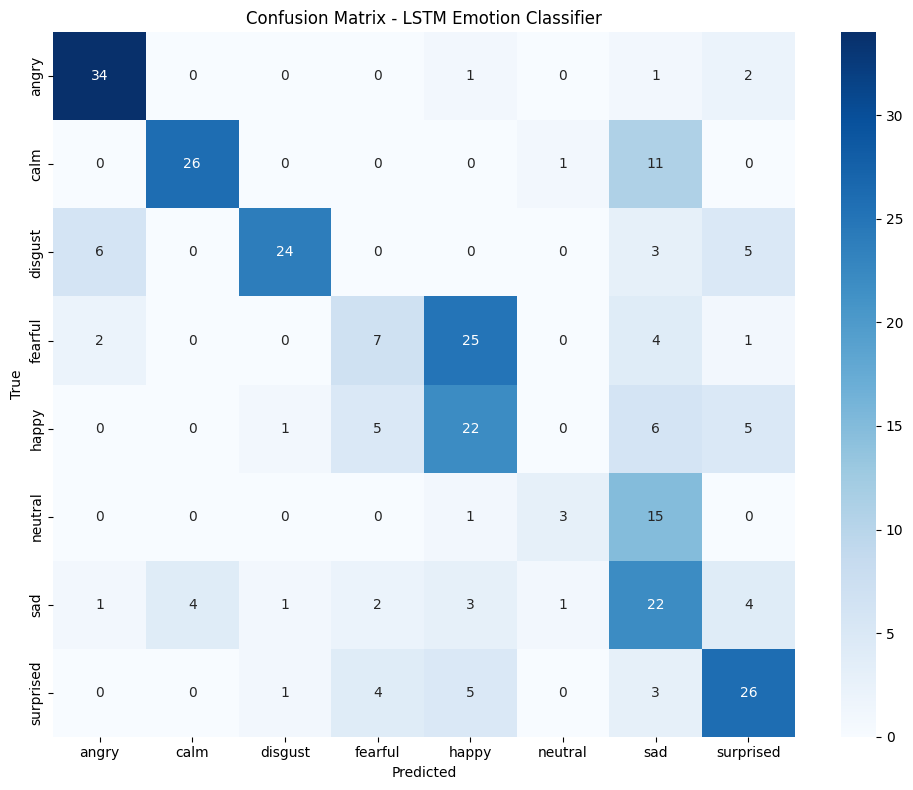

In [15]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LSTM Emotion Classifier')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

## 10. GRU Variant (Comparison)

In [16]:
class GRUEmotionClassifier(nn.Module):
    """Bidirectional GRU model for comparison."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        # Use last hidden state
        x = F.relu(self.fc1(gru_out[:, -1, :]))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Uncomment to train GRU model
# gru_model = GRUEmotionClassifier(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, n_classes).to(device)
# print(gru_model)

## 11. Key Takeaways

### Strengths of LSTM/GRU for SER
- Captures **temporal evolution** of emotions naturally
- **Bidirectional** processing leverages full context
- **Attention** can highlight key emotional moments

### Limitations
- Sequential processing = slower training than CNNs
- May struggle with very long sequences
- Sensitive to hyperparameters (layers, units, dropout)

### Next Steps
- Try CNN-LSTM hybrid (extract local features first)
- Experiment with different attention mechanisms
- Use pre-trained audio embeddings (OpenL3, VGGish)

## 12. Improvements Summary### Techniques Applied to Reduce Overfitting:| Technique | Purpose | Implementation ||-----------|---------|----------------|| **Data Augmentation** | Increase training diversity | Time stretch, pitch shift, noise || **Layer Normalization** | Stabilize training | After each LSTM layer || **Increased Dropout (0.4)** | Prevent co-adaptation | Between all layers || **Residual Connections** | Improve gradient flow | In LSTM stack || **Class Weighted Loss** | Handle imbalance | Inverse frequency weights || **Label Smoothing (0.1)** | Reduce overconfidence | Soft target labels || **L2 Regularization** | Prevent large weights | weight_decay=1e-4 || **Gradient Clipping** | Prevent exploding gradients | max_norm=1.0 || **LR Scheduler** | Adaptive learning | ReduceLROnPlateau |### Expected Benefits:- **Reduced train-test accuracy gap** (less overfitting)- **Better performance on minority classes** (fearful, neutral, sad)- **More robust feature learning**- **Improved generalization to unseen data**